In [11]:
import numpy as np
import os
int(float(str(1e9)))

1000000000

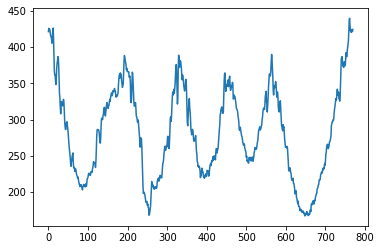

In [1]:
import numpy as np

specimen = "1"
loadstep = "1"
gauge_pitch = 0.0013
# load target
strain_meas_l = np.load(f'rebar_strains/s{specimen}_ls{loadstep}_l.npy', allow_pickle=True)
strain_meas_r = np.load(f'rebar_strains/s{specimen}_ls{loadstep}_r.npy', allow_pickle=True)

strain_meas = (strain_meas_l + strain_meas_r) / 2
strain_meas_x = np.arange(len(strain_meas))*gauge_pitch

import matplotlib.pyplot as plt

plt.plot(strain_meas)
plt.show()


In [2]:
import warp as wp
node_y = np.array([0, 0.025, 0.0487, 0.0713, 0.095, 0.12])
node_z = np.array([0, 0.025, 0.0487, 0.0713, 0.095,0.12])

wp_strain_meas = wp.from_numpy(strain_meas, dtype=float)

positions_sensors_np = np.transpose(np.meshgrid(strain_meas_x, node_y, node_z, indexing="ij"), axes=(1, 2, 3, 0)).reshape(-1, 3)
positions_sensors = wp.array(positions_sensors_np, dtype=wp.vec3)

positions_sensors_np.shape

Warp 1.11.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "Intel64 Family 6 Model 167 Stepping 1, GenuineIntel"
     "cuda:0"   : "NVIDIA GeForce RTX 3060" (12 GiB, sm_86, mempool enabled)
   Kernel cache:
     \\?\C:\Users\Jeffrey\AppData\Local\NVIDIA\warp\Cache\1.11.0


(27720, 3)

In [ ]:

import numpy as np

import warp as wp
import warp.examples.fem.utils as fem_example_utils
import warp.fem as fem
from warp.optim import Adam

import json

@wp.func
def lame_from_E_nu(E: float, nu: float) -> wp.vec2:
    # λ = Eν / ((1+ν)(1−2ν)),  μ = E / (2(1+ν))
    lam = E * nu / ((1.0 + nu) * (1.0 - nu))
    mu = E / (2.0 * (1.0 + nu))
    return wp.vec2(lam, mu)

@fem.integrand(kernel_options={"max_unroll": 1})
def boundary_projector_form(
    s: fem.Sample,
    domain: fem.Domain,
    u: fem.Field,
    v: fem.Field,
):
    return wp.dot(u(s), v(s))

@fem.integrand
def classify_boundary_sides(
    s: fem.Sample,
    domain: fem.Domain,
    left: wp.array(dtype=int),
    right: wp.array(dtype=int),
    # face_ab: wp.array(dtype=wp.float32),
    face_ab: wp.array(dtype=int),
    x_bound: wp.float32,
    z_bound: wp.float32,
):
    nor = fem.normal(domain, s)
    pos = fem.position(domain, s)

    # if nor[0] < -0.5:
    #     left[s.qp_index] = 1
    # elif nor[0] > 0.5:
    #     right[s.qp_index] = 1
    if (pos[1]>=0.0487 and pos[1]<=0.0713) and (pos[2]>=0.0487 and pos[2]<=0.0713):
        if pos[0] == 0.0:
            left[s.qp_index] = 1
        elif pos[0] == x_bound:
            right[s.qp_index] = 1
    # elif pos[2] == 0.0 or pos[2] == z_bound:
    #     face_ab[s.qp_index] = 1
    if ((pos[2]>=0.0487 and pos[2]<=0.0713)) and (pos[1]>=0.0487 and pos[1]<=0.0713):
        face_ab[s.qp_index] = 1
    # face_ab[s.qp_index] = 1
@wp.func
def hooke_stress(
    strain: wp.mat33, 
    lamb: wp.float32, 
    mu: wp.float32
):
    """Hookean elasticity"""
    return 2.0 * mu * strain + lamb * wp.trace(strain) * wp.identity(n=3, dtype=float)

@fem.integrand
def strain_field(s: fem.Sample, u: fem.Field):
    return fem.D(u, s)

@fem.integrand
def hooke_elasticity_form(
    s: fem.Sample, 
    u: fem.Field, 
    v: fem.Field, 
    E_field: fem.Field, 
    nu: float,
):
    E_val = E_field(s)
    l = lame_from_E_nu(E_val, nu)
    lamb = l[0]
    mu = l[1]
    stress = hooke_stress(fem.D(u, s), lamb, mu)
    return wp.ddot(fem.D(v, s), stress)

@fem.integrand
def applied_load_form(
    s: fem.Sample, 
    domain: fem.Domain, 
    v: fem.Field, 
    load: wp.array(dtype=wp.float32)
):
    return v(s)[0]*load[0] + v(s)[1]*load[1] + v(s)[2]*load[2]

@fem.integrand
def loss_disp(
    s: fem.Sample, 
    domain: fem.Domain, 
    u: fem.Field, 
    u_meas: fem.Field
):
    disp = u(s)
    disp_meas = u_meas(s)
    diff = disp - disp_meas
    stress_norm_sq = 0.5 * wp.dot(diff, diff)

    return stress_norm_sq 

@fem.integrand
def loss_form(
    s: fem.Sample, 
    domain: fem.Domain, 
    u: fem.Field,
    u_meas: fem.Field, 
    mask: wp.array(dtype=int),
    strain_meas_arr: wp.array(dtype=float),
    sensor_positions: wp.array(dtype=wp.vec3f),
):
    strain = strain_field(s, u)[0,0]
    strain_meas = strain_meas_arr[s.qp_index]
    diff = (strain - strain_meas)
    axial = 0.5 * (diff ** 2.0)# + (diff[1,1] ** 2.0) + (diff[2,2] ** 2.0))
    # stress_norm_sq = 0.5 * wp.ddot(diff, diff) * 1e20
    stress_norm_sq = axial * 1e20
    return stress_norm_sq #* mask[s.qp_index]



class Example:
    def __init__(
        self,
        quiet=False,
        degree=1,
        resolution=(200, 12, 12),
        mesh="tri",
        poisson_ratio=0.3,
        E=25.0e9,
        load=(1.0, 0.0, 0.0),
        lr=1.0e-3,
        strain_meas = None,
        strain_meas_x = None,
        u_meas = None,
    ):
        self._quiet = quiet
        self.degree = degree
        self.lr = lr
        # procedural rectangular domain definition
        bounds_lo = wp.vec3(0.0, 0.0, 0.0)
        bounds_hi = wp.vec3(1.0, 0.12, 0.12)
        self._initial_volume = (bounds_hi - bounds_lo)[0] * (bounds_hi - bounds_lo)[1] * (bounds_hi - bounds_lo)[2]
        
        

        self.u_meas = u_meas

        self.resolution = resolution

        # number of nodes
        node_x = np.linspace(bounds_lo[0], bounds_hi[0], self.resolution[0]+1)
        # node_y = np.linspace(bounds_lo[1], bounds_hi[1], self.resolution[1])
        # node_z = np.linspace(bounds_lo[2], bounds_hi[2], self.resolution[2])
        node_y = np.array([bounds_lo[1], 0.025, 0.0487, 0.0713, 0.095, bounds_hi[1]])
        node_z = np.array([bounds_lo[2], 0.025, 0.0487, 0.0713, 0.095, bounds_hi[2]])

        # number of elements/cells    
        self.Nx = self.resolution[0]
        self.Ny = len(node_y) - 1
        self.Nz = len(node_z) - 1

        positions_np = np.transpose(np.meshgrid(node_x, node_y, node_z, indexing="ij"), axes=(1, 2, 3, 0)).reshape(-1, 3)
        positions = wp.array(positions_np, dtype=wp.vec3)
        
        target_vals = np.array([0.0487, 0.0713])
        tol = 1e-6
        y_mask = np.isclose(positions_np[:, 1][:, None], target_vals, atol=tol).any(axis=1)
        z_mask = np.isclose(positions_np[:, 2][:, None], target_vals, atol=tol).any(axis=1)

        # self.rebar_indices = np.where(y_mask & z_mask)[0]
        n_sensor = len(strain_meas)
        extended_strain_np = np.broadcast_to(strain_meas[:, None, None], (n_sensor, self.Ny+1, self.Nz+1))
        extended_strain_np_reshape = extended_strain_np.reshape(-1)
        self.strain_meas = wp.from_numpy(extended_strain_np_reshape, dtype=float, requires_grad=True)
        positions_sensors_np = np.transpose(np.meshgrid(strain_meas_x, node_y, node_z, indexing="ij"), axes=(1, 2, 3, 0)).reshape(-1, 3)
        self.positions_sensors = wp.array(positions_sensors_np, dtype=wp.vec3, requires_grad=True)

        # print(extended_strain_np_reshape.shape, positions_sensors_np.shape)
        # sample = np.arange(100)
        # for i in sample:
        #     print(i, positions_sensors_np[i], extended_strain_np_reshape[i])
        print(positions_sensors_np)
        # print(extended_strain_np_reshape)
        if mesh == "tri":
            # triangle mesh, optimize vertices directly
            positions, tri_vidx = fem_example_utils.gen_tetmesh(
                res=wp.vec3i(resolution[0], resolution[1], resolution[2]), bounds_lo=bounds_lo, bounds_hi=bounds_hi
            )
            self._geo = fem.Tetmesh(tet_vertex_indices=tri_vidx, positions=positions, build_bvh=True)
            self._vertex_positions = positions
        elif mesh == "quad":
            vidx = fem.utils.grid_to_hexes(self.Nx, self.Ny, self.Nz)
            quad_vidx = wp.array(vidx, dtype=int)
            self._geo = fem.Hexmesh(hex_vertex_indices=quad_vidx, positions=positions, build_bvh=True)
            self._vertex_positions = positions
        else:
            # grid, optimize nodes of deformation field
            self._start_geo = fem.Grid3D(
                wp.vec3i(resolution[0], resolution[1], resolution[2]), bounds_lo=bounds_lo, bounds_hi=bounds_hi
            )
            vertex_displacement_space = fem.make_polynomial_space(self._start_geo, degree=degree, dtype=wp.vec3)
            vertex_position_field = fem.make_discrete_field(space=vertex_displacement_space)
            vertex_position_field.dof_values = vertex_displacement_space.node_positions()
            self._geo = vertex_position_field.make_deformed_geometry(relative=False)

        self.rebar_indices = np.arange(12,self._geo.cell_count(), 25)
        concrete_indices = np.delete(np.arange(self._geo.cell_count()), self.rebar_indices)

        # Store initial node positions (for rendering)
        self._u_space = fem.make_polynomial_space(self._geo, degree=degree, dtype=wp.vec3)
        self._start_node_positions = self._u_space.node_positions()

        # displacement field, make sure gradient is stored
        self._u_field = fem.make_discrete_field(space=self._u_space)
        self._u_field.dof_values.requires_grad = True

        self._u_field_meas = fem.make_discrete_field(space=self._u_space)
        self._u_field_meas.dof_values.requires_grad = True

        # Trial and test functions
        self._u_test = fem.make_test(space=self._u_space)
        self._u_trial = fem.make_trial(space=self._u_space)

        # Identify left and right sides for boundary conditions
        boundary = fem.Sides(self._geo)
        self.cells = fem.Cells(self._geo)
        left_mask = wp.zeros(shape=boundary.element_count(), dtype=int)
        right_mask = wp.zeros(shape=boundary.element_count(), dtype=int)
        # self.ab_mask = wp.zeros(shape=boundary.element_count(), dtype=float)
        self.ab_mask = wp.zeros(shape=self.cells.element_count(), dtype=int)
        print("cells: ", boundary.element_count(), self.cells.element_count())
        
        fem.interpolate(
            classify_boundary_sides,
            quadrature=fem.RegularQuadrature(boundary, order=0),
            values={"left": left_mask, 
                    "right": right_mask, 
                    "face_ab": self.ab_mask,
                    "x_bound": bounds_hi[0],
                    "z_bound": bounds_hi[2]
                    },
        )

        self._left = fem.Subdomain(boundary, element_mask=left_mask)
        self._right = fem.Subdomain(boundary, element_mask=right_mask)
        self._face = fem.Subdomain(boundary, element_mask=self.ab_mask)
        # Build projectors for the left-side homogeneous Dirichlet condition
        u_left_bd_test = fem.make_test(space=self._u_space, domain=self._left)
        u_left_bd_trial = fem.make_trial(space=self._u_space, domain=self._left)
        u_left_bd_matrix = fem.integrate(
            boundary_projector_form,
            fields={"u": u_left_bd_trial, "v": u_left_bd_test},
            assembly="nodal",
            output_dtype=float,
        )
        fem.normalize_dirichlet_projector(u_left_bd_matrix)
        self._bd_projector = u_left_bd_matrix
        

        self._nu = poisson_ratio
        self.load = load
        self._load = wp.array([load[0], load[1], load[2]], dtype=float, requires_grad=True)
        self._load.requires_grad=True

        self._u_right_test = fem.make_test(space=self._u_space, domain=self._right)


        # forward ################################################################################################

        u = self._u_field_meas.dof_values
        u.zero_()

        u_rhs = wp.empty(self._u_space.node_count(), dtype=wp.vec3f, requires_grad=True)

        E_space_meas = fem.make_polynomial_space(self._geo, degree=0, dtype=float)
        self._E_field_meas = fem.make_discrete_field(space=E_space_meas)
        E_meas_init = np.zeros((E_space_meas.node_count()))*1.0e7+25.0e9
        

        damage_idx_start = int(E_space_meas.node_count()*0.5) #- ((self.Ny)*(self.Nz))//2
        damage_idx_width = int((self.Ny)*(self.Nz))
        # damage_idx_start = int(E_space_meas.node_count()*0.5)# - ((resolution[1]+1)*(resolution[2]+1))//2
        # damage_idx_width = int((resolution[1]+1)*(resolution[2]+1))
        damage_idx = np.arange(damage_idx_start, damage_idx_start+damage_idx_width)
        E_meas_init[damage_idx] = 25.0e9*0.9
        E_meas_init[self.rebar_indices] = 200.0e9


        
        self._E_field_meas.dof_values = wp.array(E_meas_init, dtype=float, requires_grad=True)
        self._E_field_meas.dof_values.requires_grad = True

        fem.integrate(
            applied_load_form,
            fields={"v": self._u_right_test},
            values={"load": self._load},
            output=u_rhs,
        )

        u_matrix_meas = fem.integrate(
            hooke_elasticity_form,
            fields={"u": self._u_trial, "v": self._u_test, "E_field": self._E_field_meas},
            values={"nu": self._nu},
            output_dtype=float,
        )
        fem.project_linear_system(u_matrix_meas, u_rhs, self._bd_projector, normalize_projector=False)
        fem_example_utils.bsr_cg(u_matrix_meas, b=u_rhs, x=u, quiet=self._quiet, tol=1e-6, max_iters=1000)
        
        self.strain_space_meas = fem.make_polynomial_space(
            self._geo,
            degree=1,
            dtype=wp.mat33,   # tensor type
        )
        self.strain_field_meas = self.strain_space_meas.make_field().dof_values
        # print(self.strain_field_meas.dof_values.numpy().shape)
        fem.interpolate(
                strain_field,
                dest=self.strain_field_meas,
                fields={"u": self._u_field_meas},
                at=fem.NodalQuadrature(fem.Cells(self._geo), self._u_space),
                # dest_space=self.strain_space_meas,
            )
        

    # backward ################################################################################################
        # Initialize Adam optimizer
        # Current implementation assumes scalar arrays, so cast our vec2 arrays to scalars
        self.E_space = fem.make_polynomial_space(self._geo, degree=0, dtype=float)
        N = self.E_space.node_count()
        self.init_E = np.zeros(N)+25.0e9
        self.init_E[self.rebar_indices] = 200.0e9
        self.E_array = wp.array(self.init_E, dtype=float, requires_grad=True)
        self.params = wp.array(self.E_array, dtype=wp.float32).flatten()
        self.params.grad = wp.array(self.E_array.grad, dtype=wp.float32).flatten()
        self.optimizer = Adam([self.params], lr=self.lr)

    def step(self):
        self.tape = wp.Tape()

        self._E_field = fem.make_discrete_field(space=self.E_space)
        self._E_field.dof_values = self.E_array
        self._E_field.dof_values.requires_grad = True

        # Forward step, record adjoint self.tape for forces
        u_est = self._u_field.dof_values
        u_est.zero_()

        u_rhs = wp.empty(self._u_space.node_count(), dtype=wp.vec3f, requires_grad=True)

        with self.tape:
            fem.integrate(
                applied_load_form,
                fields={"v": self._u_right_test},
                values={"load": self._load},
                output=u_rhs,
            )
            # the elastic force will be zero at the first iteration,
            # but including it on the tape is necessary to compute the gradient of the force equilibrium
            # using the implicit function theorem
            # Note that this will be evaluated in the backward pass using the updated values for "_u_field"
            fem.integrate(
                hooke_elasticity_form,
                fields={"u": self._u_field, "v": self._u_test, "E_field": self._E_field},
                values={"nu": -self._nu},
                output=u_rhs,
                add=True,
            )

        u_matrix = fem.integrate(
            hooke_elasticity_form,
            fields={"u": self._u_trial, "v": self._u_test, "E_field": self._E_field},
            values={"nu": self._nu},
            output_dtype=float,
        )

        fem.project_linear_system(u_matrix, u_rhs, self._bd_projector, normalize_projector=False)
        fem_example_utils.bsr_cg(u_matrix, b=u_rhs, x=u_est, quiet=self._quiet, tol=1e-6, max_iters=1000)

        # Record adjoint of linear solve
        # (For nonlinear elasticity, this should use the final hessian, as per implicit function theorem)
        def solve_linear_system():
            fem_example_utils.bsr_cg(u_matrix, b=u_est.grad, x=u_rhs.grad, quiet=self._quiet, tol=1e-6, max_iters=1000)
            u_rhs.grad -= self._bd_projector @ u_rhs.grad
            self._u_field.dof_values.grad.zero_()

        self.tape.record_func(solve_linear_system, arrays=(u_rhs, u_est))

        # Evaluate residual
        # Integral of squared difference between simulated position and target positions
        loss = wp.empty(shape=1, dtype=wp.float32, requires_grad=True)
        with self.tape:
            fem.integrate(
                loss_form,
                # loss_disp,
                fields={"u": self._u_field, "u_meas": self._u_field_meas},
                values={"mask": self.ab_mask, "strain_meas_arr": self.strain_meas, "sensor_positions": self.positions_sensors},
                domain=self.cells,
                # quadrature=fem.PicQuadrature(self.cells, self.positions_sensors),
                output=loss,
            )

        # perform backward step
        self.tape.backward(loss=loss)

        # update positions and reset self.tape
        grad = -self.E_array.grad.numpy()
        grad[self.rebar_indices] = 0.0
        # grad = 
        self.optimizer.step([wp.array(grad, dtype=wp.float32)])
        # self.optimizer.step([-self.params.grad])
        
        self.tape.zero()
        print(loss.numpy().tolist(), grad)
        print(self.params.numpy().min(), self.params.numpy().max())

        self.strain_field = self.strain_space_meas.make_field()
        fem.interpolate(
                strain_field,
                dest=self.strain_field,
                fields={"u": self._u_field},
                # at=fem.NodalQuadrature(fem.Cells(self._geo), self._u_space)
            )

        return loss.numpy().tolist(), self.E_array.numpy().tolist()

# import argparse
# # Parse command-line arguments
# parser = argparse.ArgumentParser()
# parser.add_argument("specimen", type=str)
# parser.add_argument("loadstep", type=str)

# args = parser.parse_args()

# speciman = args.obs
# loadstep = args.snapshot

specimen = "1"
loadstep = "1"
gauge_pitch = 0.0013 # mm
# load target
strain_meas_l = np.load(f'rebar_strains/s{specimen}_ls{loadstep}_l.npy', allow_pickle=True)
strain_meas_r = np.load(f'rebar_strains/s{specimen}_ls{loadstep}_r.npy', allow_pickle=True)

strain_meas = (strain_meas_l + strain_meas_r) *1e-6 / 2 
strain_meas_x = np.arange(len(strain_meas)) * gauge_pitch
# calculate load
loads = np.array([22.2, 44.5, 89.0, 133.5, 177.9, 222.4]) * 1000
load = loads[int(loadstep)]

with wp.ScopedDevice("cuda:0"):
    
    example = Example(
        quiet=True,
        degree=1,
        resolution=(100, 6, 6),
        mesh="quad",
        poisson_ratio=0.3,
        load=wp.vec3(load/0.000509, 0.0, 0.0),
        # load=wp.vec3(200.0e3/0.000509, 0.0, 0.0),
        lr=5.0e8,
        strain_meas = strain_meas,
        strain_meas_x = strain_meas_x
    )
    
    example.step()






[[0.     0.     0.    ]
 [0.     0.     0.025 ]
 [0.     0.     0.0487]
 ...
 [0.9997 0.12   0.0713]
 [0.9997 0.12   0.095 ]
 [0.9997 0.12   0.12  ]]
cells:  8525 2500
Warp UserWarning: Quadrature used for interpolation of strain_field has different number of evaluation and indexed points, this may lead to incorrect results
[28852512768.0] [-9.5941497e-05 -3.1178151e-04 -6.4793823e-04 ... -4.8878632e-04
 -2.4119618e-04 -7.5870717e-05]
24500005000.0 200000000000.0
